# pixel diffusion with Unet

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import torch.nn.functional as F
device = "mps" if torch.backends.mps.is_available() else "cpu"


###  time embedding

In [38]:
class time_embedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        """
        B = batch_size
        t: [B]
        return: [B, dim]
        """
        device = t.device
        half_dim = self.dim // 2
        emb_scale = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb_scale)
        emb = t[:, None].float() * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        return emb


### Basic block with time embedding

In [39]:
class Block(nn.Module):
    def __init__(self, dim, dim_out, time_emb):
        super().__init__()
        self.conv1 = nn.Conv2d(dim, dim_out, 3, padding=1)
        self.conv2 = nn.Conv2d(dim_out, dim_out, 3, padding=1)
        self.time_mlp = nn.Linear(time_emb, dim_out)

        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()
    def forward(self, x, time_emb):
        """
        x: [B, C, H, W]
        time_emb: [B, time_emb]
        """
        h = F.relu(self.conv1(x))

        time_feature = self.time_mlp(time_emb)
        h = h + time_feature[:, :, None, None]

        h = F.relu(self.conv2(h))
        return h + self.res_conv(x)

### U-net

In [40]:

class Unet(nn.Module):
    def __init__(self, in_ch=3, base_ch=64, time_emb=128):
        super().__init__()
        self.time_embed = nn.Sequential(
            time_embedding(time_emb),
            nn.ReLU(),
        )
        #encoder
        self.down1 = Block(in_ch, base_ch, time_emb)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = Block(base_ch, base_ch * 2, time_emb)
        self.pool2 = nn.MaxPool2d(2)
        #bottle neck
        self.mid = Block(base_ch * 2, base_ch * 4, time_emb)
        #decoder
        self.up1 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)
        self.dec1 = Block(base_ch * 4, base_ch * 2, time_emb)
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)
        self.dec2 = Block(base_ch * 2, base_ch, time_emb)
        #output
        self.out = nn.Conv2d(base_ch, in_ch, 1)
    def forward(self,x,t):
        """
        x : [B,3,H,W]
        t : [B]
        """
        t = self.time_embed(t)
        #encoder
        x1 = self.down1(x,t)
        x2 = self.pool1(x1)
        x3 = self.down2(x2,t)
        x4 = self.pool2(x3)
        #bottle
        xm = self.mid(x4,t)
        #decoder
        u1 = self.up1(xm)
        u1 = torch.cat([u1,x3],dim=1)
        u1 = self.dec1(u1,t)

        u2 = self.up2(u1)
        u2 = torch.cat([u2,x1],dim=1)
        u2 = self.dec2(u2,t)

        out = self.out(u2)
        return out
        

Diffusion utilities

In [41]:
def linear_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, T)

def q_sample(x0, t, alpha_bars, noise):
    """
    x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise
    x0: [B, C, H, W]
    t: [B]
    alpha_bars: [T]
    noise: [B, C, H, W]
    """
    a_bar = alpha_bars[t].view(-1, 1, 1, 1).to(x0.device)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

In [42]:
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
image_dir = "/Users/jim/.cache/kagglehub/datasets/anthonytherrien/dog-vs-cat/versions/3/animals"
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
dataset = datasets.ImageFolder(root = image_dir, transform=tf)
print(len(dataset))
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

1000


## train

In [46]:
import torch.nn.functional as F
from tqdm import tqdm
T = 100
betas = linear_beta_schedule(T).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0).to(device)

model = Unet(in_ch=3, base_ch=64, time_emb=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for x0, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        x0 = x0.to(device)

        B = x0.size(0)

        # 隨機抽 timestep
        t = torch.randint(0, T, (B,), device=device)

        # 真實高斯噪聲
        noise = torch.randn_like(x0)

        # forward diffusion: x0 -> xt
        xt = q_sample(x0, t, alpha_bars, noise)

        # U-Net 預測噪聲
        pred_noise = model(xt, t)

        # loss
        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{epochs}, loss = {avg_loss:.4f}")

Epoch 1/5 [Train]: 100%|██████████| 63/63 [28:12<00:00, 26.86s/it]


Epoch 1/5, loss = 0.6726


Epoch 2/5 [Train]: 100%|██████████| 63/63 [1:06:00<00:00, 62.86s/it] 


Epoch 2/5, loss = 0.2436


Epoch 3/5 [Train]: 100%|██████████| 63/63 [50:59<00:00, 48.57s/it]   


Epoch 3/5, loss = 0.1566


Epoch 4/5 [Train]: 100%|██████████| 63/63 [1:05:05<00:00, 61.99s/it] 


Epoch 4/5, loss = 0.1198


Epoch 5/5 [Train]: 100%|██████████| 63/63 [45:20<00:00, 43.18s/it]

Epoch 5/5, loss = 0.1056


In [48]:
from pathlib import Path
save_path = Path("diffusion.pth")
torch.save(model.state_dict(),save_path)

In [52]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid, save_image

def p_sample(model, xt, t, betas, alphas, alpha_bars):
    """One reverse diffusion step."""
    beta_t = betas[t].view(-1, 1, 1, 1)
    alpha_t = alphas[t].view(-1, 1, 1, 1)
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)

    pred_noise = model(xt, t)
    mean = (xt - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * pred_noise) / torch.sqrt(alpha_t)

    noise = torch.randn_like(xt)
    nonzero_mask = (t > 0).float().view(-1, 1, 1, 1)
    return mean + nonzero_mask * torch.sqrt(beta_t) * noise

def sample_images(model, n_samples, image_size, device, betas, alphas, alpha_bars, capture_steps=None):
    model.eval()
    xt = torch.randn(n_samples, 3, image_size, image_size, device=device)
    history = {"noise": xt.detach().cpu()}
    capture_steps = set(capture_steps or [])
    with torch.no_grad():
        for step in tqdm(reversed(range(len(betas))), total=len(betas), desc="Sampling"):
            t = torch.full((n_samples,), step, device=device, dtype=torch.long)
            xt = p_sample(model, xt, t, betas, alphas, alpha_bars)
            if step in capture_steps:
                history[f"t={step}"] = xt.detach().cpu().clamp(0, 1)
    xt = xt.clamp(0, 1)
    history["final"] = xt.detach().cpu()
    return xt, history


/var/folders/jq/nkg3fdnj72dbspmxh6k5gbj40000gn/T/ipykernel_22300/1144940863.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, m

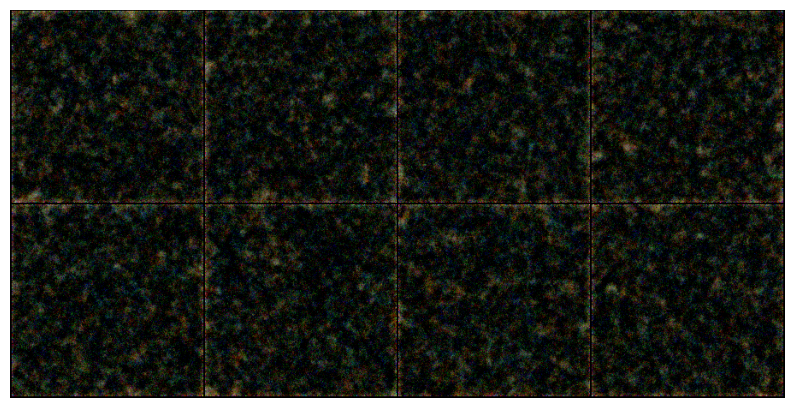

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


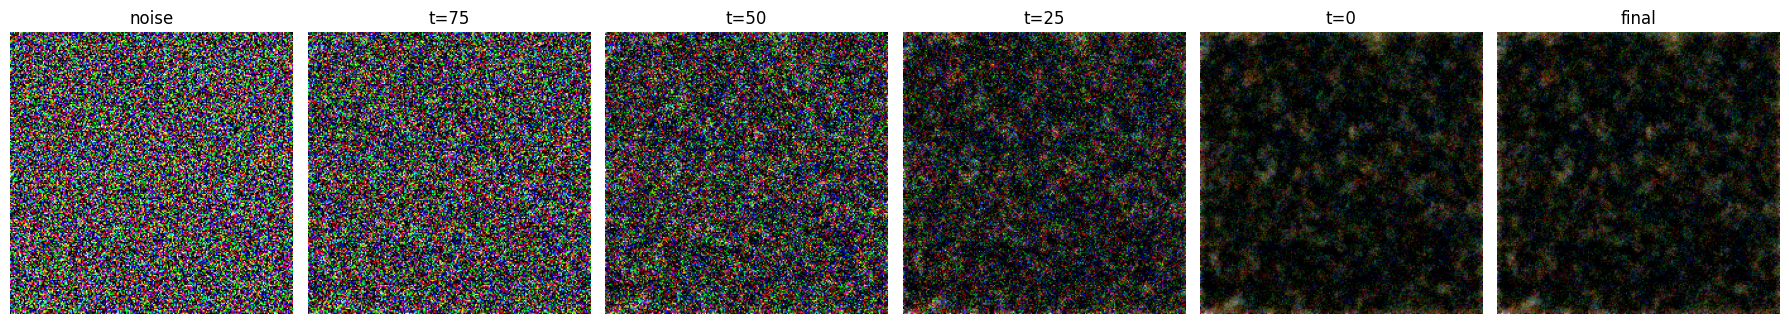

In [53]:
model.load_state_dict(torch.load(save_path, map_location=device))
samples, history = sample_images(
    model=model,
    n_samples=8,
    image_size=224,
    device=device,
    betas=betas,
    alphas=alphas,
    alpha_bars=alpha_bars,
    capture_steps=[75, 50, 25, 0],
)

grid = make_grid(samples, nrow=4)
save_image(samples, "diffusion_samples.png", nrow=4)

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()

stages = ["noise", "t=75", "t=50", "t=25", "t=0", "final"]
fig, axes = plt.subplots(1, len(stages), figsize=(18, 4))
for ax, stage in zip(axes, stages):
    image = history[stage][0].permute(1, 2, 0)
    ax.imshow(image)
    ax.set_title(stage)
    ax.axis("off")
plt.tight_layout()
plt.show()